Script: regresses out the Tropical Pacific influence and plots preci similar to O'Brien & Deser Figure 6

Notes: needs to be run individually for each model - check the boxes that have a *change me* tag on the top. 

Output files:
F6data_pr

In [2]:
# import python libs
import xarray as xr
import cartopy.crs as ccrs
import pylab as PP
import netCDF4 as nc
import numpy as np
import matplotlib as mpl
import pickle
from eofs.standard import Eof
import copy
from cartopy.util import add_cyclic_point


# import my libs (this lib is used for linregress 3D)
#from c20c_pr40d_pyfxns import c20c_40d_fxns as c20c


#Set the default font for plots
font = { 'family' : 'sans-serif', \
         'size' : '15', \
         'weight' : 'bold'}
mpl.rc('font', **font)
mpl.rc('axes', labelweight = 'bold') # needed for bold axis labels in more recent version of matplotlib

%load_ext autoreload
%autoreload 2


ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [3]:
#define linear regression function

def linregress_3D(x, y):
    """

    Input:
    x: one dimentional array to regress against
    y: 3 dimentionsal array (time,lat,lon)

    the first dimention of y must be the same length of x

    return: slope,intercept,pval,cor,stderr,cov on regression
    between the two datasets along their aligned dimension.

    The output format and data are exactly identical to numpy's linregress

    """

    # broadcast the input x array to be the same shape as input y array
    x = np.array(np.broadcast_to(x[:,np.newaxis,np.newaxis],y.shape))

    # mask invalid locations in y
    ym = np.ma.masked_invalid(y)
    # apply the same mask to x
    xm = np.ma.masked_array(x, mask=ym.mask)

    #3. Compute data length, mean and standard deviation along time axis for further use:
    n     = xm.shape[0]
    xmean = xm.mean(axis=0)
    ymean = ym.mean(axis=0)
    xstd  = xm.std(axis=0)
    ystd  = ym.std(axis=0)

    #4. Compute covariance along time axis
    cov   =  np.sum(np.multiply((xm - xmean),(ym - ymean)), axis=0)/(n-1)
    #covxx   =  np.sum(np.multiply((xm - xmean),(xm - xmean).T), axis=0)/(n-1)
    #covyy   =  np.sum(np.multiply((ym - ymean),(ym - ymean).T), axis=0)/(n-1)
    #print(cov.shape)

    #5. Compute correlation along time axis
    cor   = cov/(xstd*ystd)

    #6. Compute regression slope and intercept:
    slope     = cov/(xstd**2)
    intercept = ymean - xmean*slope

    #7. Compute P-value and standard error
    # Compute t-statistics
    TINY = 1.0e-20
    tstats = cor*np.sqrt((n-2)/((1.0 - cor + TINY)*(1.0 + cor + TINY)))
    stderr = slope/tstats

    df = n-2
    #stderr = np.sqrt((1 - cor**2) * covxx / covyy / df)

    from scipy.stats import t
    pval   = 2*t.sf(x=np.abs(tstats), df=df)
    #pval   = xr.DataArray(pval, dims=cor.dims, coords=cor.coords)

    return slope, intercept, cor, pval, stderr

In [4]:
#*change me*
#set up the data directory and load in lon + lat + time dimensions
outputdir='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
outputdir2='/glade/work/nmaher/SEOF_output/'
outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'


model='MPI-GE'

#tell me when the start year is 
syear=1850
offset=1921-syear


#load lon lat should be same for all models
ds_fx = xr.open_dataset(outputdir+'zg_Amon_CESM1-CAM5_historical_rcp85_r1i1p1_192001-210012_g025.nc')

lons = ds_fx.lon
lats = ds_fx.lat

#load zg500 DJF with emen removed

eof_T='_zgDJFerem'
with np.load(outputdir2+model+eof_T+'_SEOF.npz') as npz:
    z500_djf_anom = np.ma.MaskedArray(**npz)
z500_djf_anom.shape



(100, 249, 72, 144)

In [5]:
#load dimensions
ne=len(z500_djf_anom[:,0,0,0])*5
ntt=len(z500_djf_anom[0,:,0,0])


In [6]:
#*change me*
#load precip file

eof_T='_prDJFerem'
with np.load(outputdir2+model+eof_T+'_SEOF.npz') as npz:
    pr_djf_dm = np.ma.MaskedArray(**npz)
pr_djf_dm.shape

#if model=='CESM2-LE_SMBB' or 'CESM2-LE_CMIP6' or 'CESM2-LE_FULL':
 #   print(model)
  #  pr_djf_dm=pr_djf_dm*1000

(100, 249, 72, 144)

In [7]:
#load TPAC SST EOFs

eof_T='_TPAC_SST'

with np.load(outputdir2+model+eof_T+'_SPCS.npz') as npz:
    tpac_spcs2 = np.ma.MaskedArray(**npz)
with np.load(outputdir2+model+eof_T+'_SEOF.npz') as npz:
    tpac_seof = np.ma.MaskedArray(**npz)


In [8]:
#*change me*

#make sure SPCs and EOFs are the same way around
pattCorr_array = np.ma.masked_equal(np.zeros([2,ntt-5]),0)

for i in range(ntt-5):

    eof0a = tpac_seof[0,0,...].flatten() - tpac_seof[0,0,...].mean()
    eof1a = tpac_seof[i,0,...].flatten() - tpac_seof[i,0,...].mean()
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    pattCorr_array[0,i] = num
    eof0b = tpac_seof[0,1,...].flatten() - tpac_seof[0,1,...].mean()
    eof1b = tpac_seof[i,1,...].flatten() - tpac_seof[i,1,...].mean()
    numb = np.sum(eof0b*eof1b)/np.sqrt(np.sum(eof0b**2)*np.sum(eof1b**2))
    pattCorr_array[1,i] = numb

'''
after you poplulate the pattern corr array. use it like so to flip all the
spcs with negitive correlations
'''

# copy your arrays to preserve the original ones in case you need them for later
# flipping happens in place

tpac_seof_tmp = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)
tpac_seof_phcorr = np.ma.masked_array(tpac_seof,mask=tpac_seof.mask,copy=True)

tpac_spcs_tmp = np.array(tpac_spcs2,copy=True)
tpac_spcs = np.array(tpac_spcs2,copy=True)


# flip seofs/spcs 0

# get the indices with negitive/positive correlations.
# note here it turns out that the first seof I was correlating against
# had the incorrect phase so Im flipping all the positive phased ones
# to avoid doing this (it doesnt matter much tbh) just set the phase of the first
# seof to what you want it before calculating the pattern correlations

ineg = np.nonzero(pattCorr_array[0,:]>0)[0]

tpac_seof_phcorr[ineg,0,...] = -1*tpac_seof_tmp[ineg,0,...]
tpac_spcs[ineg,:,0] = -1*tpac_spcs_tmp[ineg,:,0]


# flip seofs/spcs 1

ineg = np.nonzero(pattCorr_array[1,:]>0)[0]

tpac_seof_phcorr[ineg,1,...] = -1*tpac_seof_tmp[ineg,1,...]
tpac_spcs[ineg,:,1] = -1*tpac_spcs_tmp[ineg,:,1]

#flip EOF1 to be consistent with other plots - for CESM1
tpac_spcs[:,:,0]=tpac_spcs[:,:,0]*-1
tpac_seof_phcorr[:,0,:,:]=tpac_seof_phcorr[:,0,:,:]*-1
#save for CESM1 then decide on output phase
np.savez_compressed(outputdir2+model+'_tpac_spcs_phasecorrect.npz', data=tpac_seof_phcorr.data)

#*change me*
#model2='CESM1-LE'

#with np.load(outputdir2+model2+'_tpac_spcs_phasecorrect.npz') as npz:
 #   tpac_cesm = np.ma.MaskedArray(**npz)


#for i in range(2):
#    eof0a = tpac_cesm[0,i,...].flatten() 
#    eof1a = tpac_seof_phcorr[0,i,:,:].flatten() 
#    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
#    if num<0:
#        tpac_spcs[:,:,i]=tpac_spcs[:,:,i]*-1

In [9]:
# remove the TPac correltaions from the z500 field

z500_djf_anom_eof12rm_seof_darr = np.ma.masked_equal(np.zeros([ntt-5,ne,72,144]),0)

z500_djf_anom_rs_darr = np.ma.masked_equal(np.zeros([ntt-5,ne,72,144]),0)

for i in range(ntt-5)[:]:

    z500_djf_anom_rs = z500_djf_anom[:,i:i+5,...].reshape(-1,72,144)
    z500_djf_anom_rs_darr[i,...] = z500_djf_anom_rs

    z500_ens_pc_reg_eof1 = linregress_3D(tpac_spcs[i,:,0], z500_djf_anom_rs)

    slopes1,intercepts1 = z500_ens_pc_reg_eof1[0],z500_ens_pc_reg_eof1[1]

    linregressions_eof1 = slopes1[np.newaxis,:,:]*tpac_spcs[i,:,0][:,np.newaxis,np.newaxis]+intercepts1[np.newaxis,:,:]

    z500_djf_anom_rs_eof1rm = z500_djf_anom_rs - linregressions_eof1
        
    
    
    z500_ens_pc_reg_eof2 = linregress_3D(tpac_spcs[i,:,1], z500_djf_anom_rs_eof1rm)

    slopes2,intercepts2 = z500_ens_pc_reg_eof2[0],z500_ens_pc_reg_eof2[1]

    linregressions_eof2 = slopes2[np.newaxis,:,:]*tpac_spcs[i,:,1][:,np.newaxis,np.newaxis]+intercepts2[np.newaxis,:,:]

    z500_djf_anom_rs_eof12rm = z500_djf_anom_rs_eof1rm - linregressions_eof2
    
    z500_djf_anom_eof12rm_seof_darr[i,...] = z500_djf_anom_rs_eof12rm
    

In [10]:
# now mask the tpac decorlated field over the pna region

lat_range=[20,90]
lon_range=[110,260]

ilat = lats<20
ilon = np.logical_or(lons<110,lons>260)

ilat_tmp=np.array(ilat)
ilon_tmp=np.array(ilon)

ilat2d = np.broadcast_to(ilat_tmp[:,np.newaxis], z500_djf_anom_eof12rm_seof_darr[0,0,...].shape)
ilon2d = np.broadcast_to(ilon_tmp[np.newaxis,:], z500_djf_anom_eof12rm_seof_darr[0,0,...].shape)

mask2d = np.logical_or(ilat2d,ilon2d)
mask4d = np.broadcast_to(mask2d[np.newaxis,np.newaxis,:,:],z500_djf_anom_eof12rm_seof_darr.shape)

z500_djf_anom_eof12rm_seof_darr_ma = np.ma.masked_array(z500_djf_anom_eof12rm_seof_darr,mask=mask4d)

In [11]:
# compute the eofs of the tpac decorlated field

# create eof weights
coslat = np.cos(np.deg2rad(lats))
coslat_tmp=np.array(coslat)
wgts = np.broadcast_to(np.sqrt(coslat_tmp)[np.newaxis,:,np.newaxis], z500_djf_anom_eof12rm_seof_darr_ma[0,...].shape)


npac_seof_tpac_res_uncorr_arr = np.ma.masked_equal(np.zeros([ntt-5,3,72,144]),0)
npac_spcs_tpac_res_uncorr_arr = np.ma.masked_equal(np.zeros([ntt-5,ne,3]),0)

npac_seof_tpac_res_fracVarExp_arr = np.ma.masked_equal(np.zeros([ntt-5,3]),0)
npac_seof_tpac_res_totalVar_arr = np.ma.masked_equal(np.zeros([ntt-5,1]),0)



In [12]:

for i in range(ntt-5)[:]:
    
    solver = Eof(z500_djf_anom_eof12rm_seof_darr_ma[i,...], weights=wgts)
    
    
    eofs = solver.eofs(neofs=3, eofscaling=2)
    pcs = solver.pcs(npcs=3,pcscaling=1)
    fracvar = solver.varianceFraction(neigs=3)
    total_variance = solver.totalAnomalyVariance()
    
    npac_seof_tpac_res_uncorr_arr[i,...] = eofs      
    npac_spcs_tpac_res_uncorr_arr[i,...] = pcs
    
    npac_seof_tpac_res_fracVarExp_arr[i,...] = fracvar
    npac_seof_tpac_res_totalVar_arr[i,...] = total_variance

In [13]:
pattCorr_array_dr_uncorr_pna = np.ma.masked_equal(np.zeros([3,ntt-5]),0)

for i in range(ntt-5)[:]:
               
    eof0a = npac_seof_tpac_res_uncorr_arr[0,0,...].flatten() - npac_seof_tpac_res_uncorr_arr[0,0,...].mean()

    eof1a = npac_seof_tpac_res_uncorr_arr[i,0,...].flatten() - npac_seof_tpac_res_uncorr_arr[i,0,...].mean()

    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))

    pattCorr_array_dr_uncorr_pna[0,i] = num
    
    
               
    eof0a = npac_seof_tpac_res_uncorr_arr[0,1,...].flatten() - npac_seof_tpac_res_uncorr_arr[0,1,...].mean()

    eof1a = npac_seof_tpac_res_uncorr_arr[i,1,...].flatten() - npac_seof_tpac_res_uncorr_arr[i,1,...].mean()

    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))

    pattCorr_array_dr_uncorr_pna[1,i] = num
    

               
    eof0a = npac_seof_tpac_res_uncorr_arr[0,2,47:65,0:140].flatten() - npac_seof_tpac_res_uncorr_arr[0,2,47:65,0:140].mean()

    eof1a = npac_seof_tpac_res_uncorr_arr[i,2,47:65,0:140].flatten() - npac_seof_tpac_res_uncorr_arr[i,2,47:65,0:140].mean()

    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))

    pattCorr_array_dr_uncorr_pna[2,i] = num
        


In [14]:
# phase correct the resulting spcs using the pattern correlations

mask = npac_seof_tpac_res_uncorr_arr.mask

# create temperary copies of arrays

npac_seof_tpac_res_uncorr_arr_tmp = np.ma.masked_array(npac_seof_tpac_res_uncorr_arr,mask=mask,copy=True)
npac_seof_tpac_res_phcorr_arr = np.ma.masked_array(npac_seof_tpac_res_uncorr_arr,mask=mask,copy=True)

npac_spcs_tpac_res_uncorr_arr_tmp = np.array(npac_spcs_tpac_res_uncorr_arr,copy=True)
npac_spcs_tpac_res_phcorr_arr = np.array(npac_spcs_tpac_res_uncorr_arr,copy=True)


# flip the first spcs

ineg = np.nonzero(pattCorr_array_dr_uncorr_pna[0,:]>0)[0]

npac_seof_tpac_res_phcorr_arr[ineg,0,...] = -1*npac_seof_tpac_res_uncorr_arr_tmp[ineg,0,...]
npac_spcs_tpac_res_phcorr_arr[ineg,:,0] = -1*npac_spcs_tpac_res_uncorr_arr_tmp[ineg,:,0]


# flip the second spcs

ineg = np.nonzero(pattCorr_array_dr_uncorr_pna[1,:]<0)[0]

npac_seof_tpac_res_phcorr_arr[ineg,1,...] = -1*npac_seof_tpac_res_uncorr_arr_tmp[ineg,1,...]
npac_spcs_tpac_res_phcorr_arr[ineg,:,1] = -1*npac_spcs_tpac_res_uncorr_arr_tmp[ineg,:,1]


# flip the third spcs

ineg = np.nonzero(pattCorr_array_dr_uncorr_pna[2,:]<0)[0]

npac_seof_tpac_res_phcorr_arr[ineg,2,...] = -1*npac_seof_tpac_res_uncorr_arr_tmp[ineg,2,...]
npac_spcs_tpac_res_phcorr_arr[ineg,:,2] = -1*npac_spcs_tpac_res_uncorr_arr_tmp[ineg,:,2]
        
        

In [15]:
# mask the tpac decorr field outside the nao region

lat_range=[20,90]
lon_range=[280,10]

ilat = lats<20
ilon = ~np.logical_or(lons<10,lons>280)


ilat_tmp=np.array(ilat)
ilon_tmp=np.array(ilon)

ilat2d = np.broadcast_to(ilat_tmp[:,np.newaxis], z500_djf_anom_eof12rm_seof_darr[0,0,...].shape)
ilon2d = np.broadcast_to(ilon_tmp[np.newaxis,:], z500_djf_anom_eof12rm_seof_darr[0,0,...].shape)

mask2d = np.logical_or(ilat2d,ilon2d)
mask4d = np.broadcast_to(mask2d[np.newaxis,np.newaxis,:,:],z500_djf_anom_eof12rm_seof_darr.shape)

z500_djf_anom_eof12rm_seof_darr_nao_ma = np.ma.masked_array(z500_djf_anom_eof12rm_seof_darr,mask=mask4d)

In [16]:
# calculate the tpac decolrated eofs

# create eof weights
coslat = np.cos(np.deg2rad(lats))
coslat_tmp=np.array(coslat)
wgts = np.broadcast_to(np.sqrt(coslat_tmp)[np.newaxis,:,np.newaxis], z500_djf_anom_eof12rm_seof_darr_ma[0,...].shape)


nao_seof_uncorr_arr = np.ma.masked_equal(np.zeros([ntt-5,1,72,144]),0)
nao_spcs_uncorr_arr = np.ma.masked_equal(np.zeros([ntt-5,ne,1]),0)

nao_seof_fracVarExp_arr = np.ma.masked_equal(np.zeros([ntt-5,1]),0)
nao_seof_totalVar_arr = np.ma.masked_equal(np.zeros([ntt-5,1]),0)


for i in range(ntt-5)[:]:
    
    solver = Eof(z500_djf_anom_eof12rm_seof_darr_nao_ma[i,...], weights=wgts)
    
    
    eofs = solver.eofs(neofs=1, eofscaling=2)
    pcs = solver.pcs(npcs=1,pcscaling=1)
    fracvar = solver.varianceFraction(neigs=1)
    total_variance = solver.totalAnomalyVariance()
    
    nao_seof_uncorr_arr[i,...] = eofs      
    nao_spcs_uncorr_arr[i,...] = pcs
    
    nao_seof_fracVarExp_arr[i,...] = fracvar
    nao_seof_totalVar_arr[i,...] = total_variance

In [17]:
pattCorr_array_dr_uncorr_pna = np.ma.masked_equal(np.zeros([1,ntt-5]),0)

for i in range(ntt-5)[:]:
               
    eof0a = nao_seof_uncorr_arr[0,0,...].flatten() - nao_seof_uncorr_arr[0,0,...].mean()

    eof1a = nao_seof_uncorr_arr[i,0,...].flatten() - nao_seof_uncorr_arr[i,0,...].mean()

    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))

    pattCorr_array_dr_uncorr_pna[0,i] = num
    
    
               
  

In [18]:
# phase correct the nao tpac decorr spcs

mask = nao_seof_uncorr_arr.mask


nao_seof_uncorr_arr_tmp = np.ma.masked_array(nao_seof_uncorr_arr,mask=mask,copy=True)
nao_seof_phcorr_arr = np.ma.masked_array(nao_seof_uncorr_arr,mask=mask,copy=True)

nao_spcs_uncorr_arr_tmp = np.array(nao_spcs_uncorr_arr,copy=True)
nao_spcs_phcorr_arr = np.array(nao_spcs_uncorr_arr,copy=True)


        
ineg = np.nonzero(pattCorr_array_dr_uncorr_pna[0,:]>0)[0]

nao_seof_phcorr_arr[ineg,0,...] = -1*nao_seof_uncorr_arr_tmp[ineg,0,...]
nao_spcs_phcorr_arr[ineg,:,0] = -1*nao_spcs_uncorr_arr_tmp[ineg,:,0]


      

In [19]:
# cat the decorr spcs into one array
spcs_tpac_res = np.concatenate([npac_spcs_tpac_res_phcorr_arr, nao_spcs_phcorr_arr],axis=-1)
spcs_tpac_res.shape

(244, 500, 4)

In [20]:
# now regess the phase corrected seof principal components against the z500 ensemble dimention

z500_spc_ens_reg_slopes = np.ma.masked_equal(np.zeros((4,ntt-5,72,144)),0)
z500_spc_ens_reg_pvals = np.ma.masked_equal(np.zeros((4,ntt-5,72,144)),0)
z500_spc_ens_reg_corrcoef = np.ma.masked_equal(np.zeros((4,ntt-5,72,144)),0)


for j in range(4):
    print(j)
    for i in range(ntt-5)[:]:

        z500_rs = z500_djf_anom[:,i:i+5,...].reshape(-1,72,144)

        #print(pr_rs.shape)

        z_ens_pc_reg = linregress_3D(spcs_tpac_res[i,:,j], z500_rs)

        z500_spc_ens_reg_slopes[j,i,...] = z_ens_pc_reg[0]
        z500_spc_ens_reg_pvals[j,i,...] = z_ens_pc_reg[3]
        z500_spc_ens_reg_corrcoef[j,i,...] = z_ens_pc_reg[2]

0
1
2
3


In [21]:
# now regess the phase corrected seof principal components against the precip ensemble dimention

pr_spc_ens_reg_slopes = np.ma.masked_equal(np.zeros((4,ntt-5,72,144)),0)
pr_spc_ens_reg_pvals = np.ma.masked_equal(np.zeros((4,ntt-5,72,144)),0)
pr_spc_ens_reg_corrcoef = np.ma.masked_equal(np.zeros((4,ntt-5,72,144)),0)

#pr_djf_dm = pr_djf - np.average(pr_djf, axis=0)[np.newaxis,:,:,:]

for j in range(4):
    print(j)
    for i in range(ntt-5)[:]:

        pr_rs = pr_djf_dm[:,i:i+5,...].reshape(-1,72,144)

        #print(pr_rs.shape)

        pr_ens_pc_reg = linregress_3D(spcs_tpac_res[i,:,j], pr_rs)

        pr_spc_ens_reg_slopes[j,i,...] = pr_ens_pc_reg[0]
        pr_spc_ens_reg_pvals[j,i,...] = pr_ens_pc_reg[3]
        pr_spc_ens_reg_corrcoef[j,i,...] = pr_ens_pc_reg[2]

0
1
2
3


In [22]:
#*change me* 

#save for CESM1 then decide on output phase
#np.savez_compressed(outputdir2+model+'_pr_reg_slope_phasecprrect.npz', data=pr_spc_ens_reg_slopes.data)
#np.savez_compressed(outputdir2+model+'_z500_reg_slope_phasecprrect.npz', data=z500_spc_ens_reg_slopes.data)


In [23]:
#make everything else match CESM1-LE
model2='CESM1-LE'

with np.load(outputdir2+model2+'_pr_reg_slope_phasecprrect.npz') as npz:
    pr_cesm = np.ma.MaskedArray(**npz)
with np.load(outputdir2+model2+'_z500_reg_slope_phasecprrect.npz') as npz:
    z500_cesm = np.ma.MaskedArray(**npz)

for i in range(4):
    eof0a = pr_cesm[i,0,...].flatten() 
    eof1a = pr_spc_ens_reg_slopes[i,0,:,:].flatten() 
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    if num<0:
        pr_spc_ens_reg_slopes[i,:,:,:]=pr_spc_ens_reg_slopes[i,:,:,:]*-1
        
for i in range(4):
    eof0a = z500_cesm[i,0,...].flatten() 
    eof1a = z500_spc_ens_reg_slopes[i,0,:,:].flatten() 
    num = np.sum(eof0a*eof1a)/np.sqrt(np.sum(eof0a**2)*np.sum(eof1a**2))
    if num<0:
        z500_spc_ens_reg_slopes[i,:,:,:]=z500_spc_ens_reg_slopes[i,:,:,:]*-1

In [24]:
pr_spc_ens_reg_slopes=pr_spc_ens_reg_slopes*86400

In [25]:
eof_T='_F6data_pr'
np.savez_compressed(outputdir_figD+model+eof_T+'.npz', data=pr_spc_ens_reg_slopes.data)

eof_T='_F6data_zg'
np.savez_compressed(outputdir_figD+model+eof_T+'.npz', data=z500_spc_ens_reg_slopes.data)

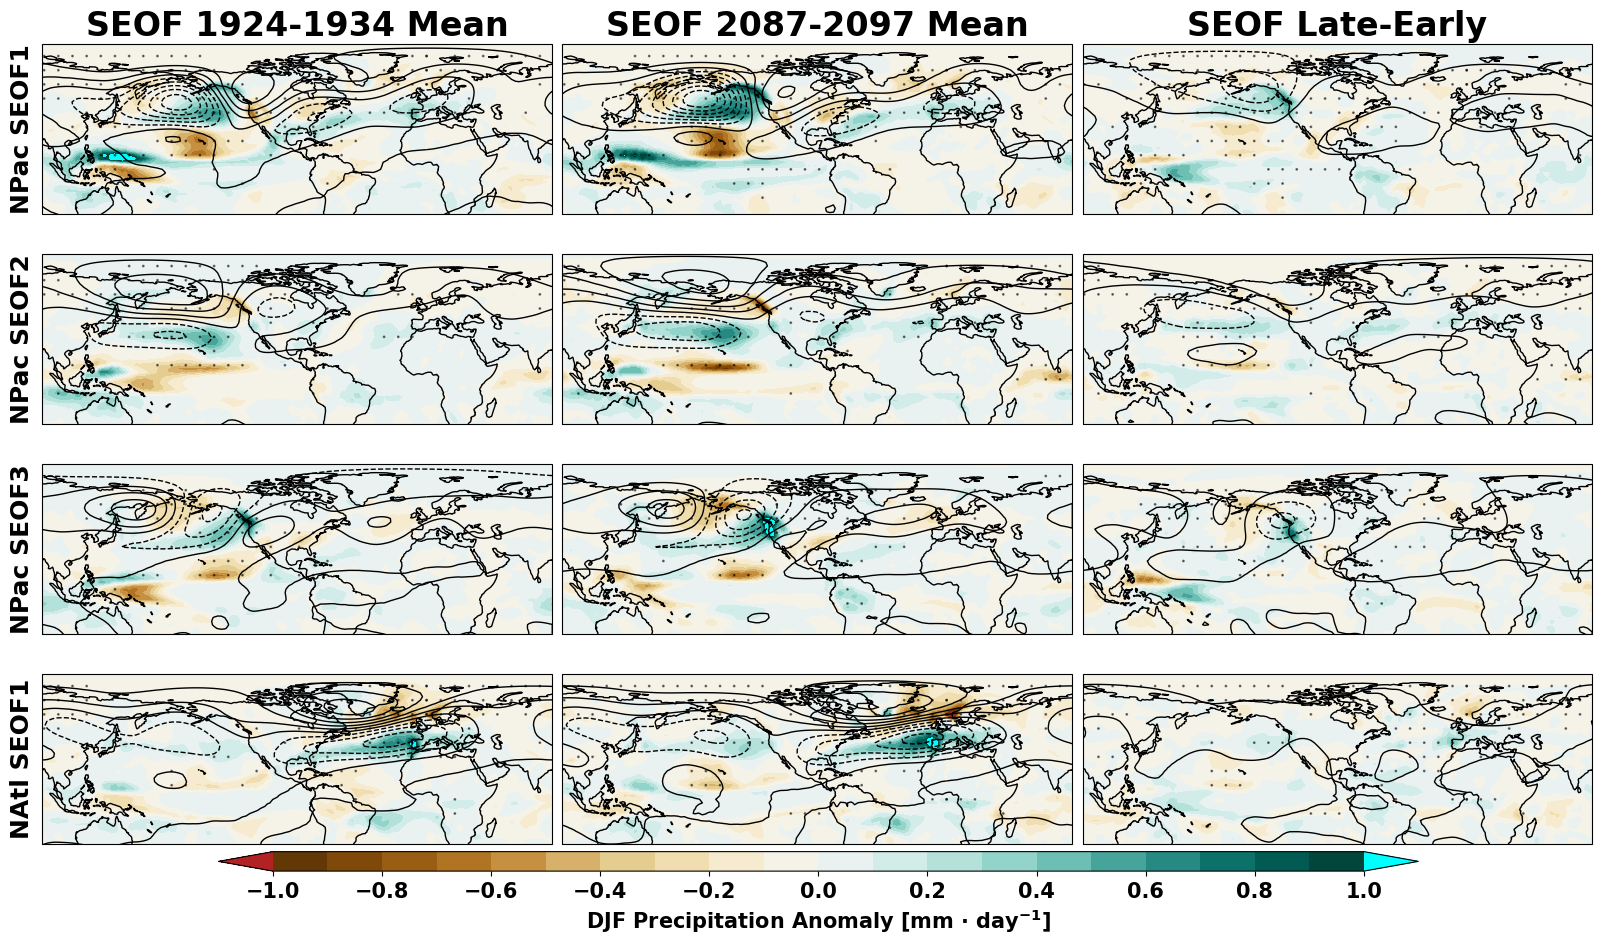

In [26]:
# make the z500/PR 4-panel plot

fig,axs = PP.subplots(4,3,figsize=(20,15), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=270)})

#levels = np.linspace(-60,60,21)
levels = np.arange(-1,1.1,0.1)
clevels = np.arange(-80,82.5,2.5)[::4]

cmap = copy.deepcopy(mpl.cm.BrBG)
cmap.set_over('cyan')
cmap.set_under('firebrick')

panel_labels = np.array(['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)'])


# define 2d lat and lon points for ploting sig locs
lon2d,lat2d = np.meshgrid(lons,lats)

cnt = 0

for i in range(4): # 4 pr_spc_ens_reg_pvals
    
    
    cdata,clons = add_cyclic_point(pr_spc_ens_reg_slopes[i,0+offset:10+offset,...].mean(axis=0),lons)
    cplt = axs[i,0].contourf(clons,lats,cdata, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')

    cdataf,clons = add_cyclic_point(z500_spc_ens_reg_slopes[i,0+offset:10+offset,...].mean(axis=0),lons)
    cpltc = axs[i,0].contour(clons,lats,cdataf, transform=ccrs.PlateCarree(), levels=clevels, colors='k', linewidths=1.0)

    
    
    cdata2,clons2 = add_cyclic_point(pr_spc_ens_reg_slopes[i,164+offset:174+offset,...].mean(axis=0),lons)
    cplt = axs[i,1].contourf(clons2,lats,cdata2, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')

    cdataf2,clons2 = add_cyclic_point(z500_spc_ens_reg_slopes[i,164+offset:174+offset,...].mean(axis=0),lons)
    cpltc = axs[i,1].contour(clons2,lats,cdataf2, transform=ccrs.PlateCarree(), levels=clevels, colors='k', linewidths=1.0)

    cplt2 = axs[i,2].contourf(clons2,lats,cdata2-cdata, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')
    cpltc2 = axs[i,2].contour(clons2,lats,cdataf2-cdataf, transform=ccrs.PlateCarree(), levels=clevels, colors='k', linewidths=1.0)



    sig_locs = np.ma.sum(pr_spc_ens_reg_pvals[i,:10,...]<=0.01, axis=0)>=8
    sig_lons = np.ma.masked_array(lon2d, mask=~sig_locs)
    sig_lats = np.ma.masked_array(lat2d, mask=~sig_locs)
    clatsp,clonspt = add_cyclic_point(sig_lats,lons)
    clonsp,clonspt = add_cyclic_point(sig_lons,lons)
    clocsp,clonspt = add_cyclic_point(sig_locs,lons)

    skip=4
    axs[i,0].scatter(clonsp[::skip,::skip], clatsp[::skip,::skip], c='k', s=clocsp.astype('int')[::skip,::skip], transform=ccrs.PlateCarree(), alpha=0.5)

    axs[i,0].coastlines()
    axs[i,0].set_ylim(-30,90)

    #axs[i,0].text(0.04,0.9,panel_labels[::2][cnt], fontsize=16, ha='center', va='center', transform=axs[i,0].transAxes,
                # bbox=dict(facecolor='white', edgecolor='k', pad=5.0))
                                   
                                   
    sig_locs = np.ma.sum(pr_spc_ens_reg_pvals[i,-10:,...]<=0.01, axis=0)>=8
    sig_lons = np.ma.masked_array(lon2d, mask=~sig_locs)
    sig_lats = np.ma.masked_array(lat2d, mask=~sig_locs)
    clatsp,clonspt = add_cyclic_point(sig_lats,lons)
    clonsp,clonspt = add_cyclic_point(sig_lons,lons)
    clocsp,clonspt = add_cyclic_point(sig_locs,lons)

    skip=4
    axs[i,1].scatter(clonsp[::skip,::skip], clatsp[::skip,::skip], c='k', s=clocsp.astype('int')[::skip,::skip], transform=ccrs.PlateCarree(), alpha=0.5)

    axs[i,1].coastlines()
    axs[i,1].set_ylim(-30,90)

    #axs[i,1].text(0.04,0.9,panel_labels[1::2][cnt], fontsize=16, ha='center', va='center', transform=axs[i,1].transAxes,
               #  bbox=dict(facecolor='white', edgecolor='k', pad=5.0))
    
    skip=4
    axs[i,2].scatter(clonsp[::skip,::skip], clatsp[::skip,::skip], c='k', s=clocsp.astype('int')[::skip,::skip], transform=ccrs.PlateCarree(), alpha=0.5)

    axs[i,2].coastlines()
    axs[i,2].set_ylim(-30,90)

    #axs[i,2].text(0.04,0.9,panel_labels[1::2][cnt], fontsize=16, ha='center', va='center', transform=axs[i,1].transAxes,
                 #bbox=dict(facecolor='white', edgecolor='k', pad=5.0))

    cnt += 1


PP.text(-0.04,0.5,'NPac SEOF1', rotation=90, fontsize=18, ha='center', va='center', transform=axs[0,0].transAxes)
PP.text(-0.04,0.5,'NPac SEOF2', rotation=90, fontsize=18, ha='center', va='center', transform=axs[1,0].transAxes)
PP.text(-0.04,0.5,'NPac SEOF3', rotation=90, fontsize=18, ha='center', va='center', transform=axs[2,0].transAxes)
PP.text(-0.04,0.5,'NAtl SEOF1', rotation=90, fontsize=18, ha='center', va='center', transform=axs[3,0].transAxes)


axs[0,0].set_title('SEOF 1924-1934 Mean', fontsize=24, weight='bold')
axs[0,1].set_title('SEOF 2087-2097 Mean', fontsize=24, weight='bold')
axs[0,2].set_title('SEOF Late-Early', fontsize=24, weight='bold')

PP.subplots_adjust(hspace=-0.6,wspace=0.02)

cticks = np.linspace(-1,1,21)

cbar_ax = fig.add_axes([0.213, 0.21, 0.6, 0.013])

cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=cticks[::2])
cbar.set_label('DJF Precipitation Anomaly [mm $\cdot$ day$^{-1}$]')
        
figdir = None
#PP.savefig(figdir+"somewhere")
PP.savefig(outputdir2+model+'Figure6b.png', dpi=300, bbox_inches='tight')
    
PP.show()